## Exercise 


For this exercise, you will be working with the [House Price Dataset](https://www.kaggle.com/competitions/house-prices-advanced-regression-techniques/code).

Please grab the train.csv file from Kaggle and explore this dataset. You need to perform explroatory data analysis and see if there is any correlation between the variables and analyze the distribution of the dataset. The question is open-ended and basically you're asked to perform EDA. 


1- Write a summary of your findings in one page (e.g., summary statistics, plots) and submit the pdf file. Therefore, for part 3 of your assignment, you need to submit at least one jupyter notebook file and one pdf file.


2- Push your code and project to github and provide the link to your code here. Ensure that your github project is organized to at least couple of main folders, ensure that you have the README file as well:

- Src
- Data
- Docs
- Results

Read this link for further info:  https://gist.github.com/ericmjl/27e50331f24db3e8f957d1fe7bbbe510





In [24]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv("train.csv")

# Display basic info
df.info()
df.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


**Checking Missing Values**

In [29]:
# Checking Missing Values
missing_values = df.isnull().sum()
missing_values = missing_values[missing_values > 0].sort_values(ascending=False)
missing_values_df = pd.DataFrame({'Column': missing_values.index, 'Missing Count': missing_values.values, 
                                  'Missing Percentage': (missing_values.values / len(df)) * 100})

# Display missing values summary
missing_values_df

,Column,Missing Count,Missing Percentage
0,PoolQC,1453,99.520548
1,MiscFeature,1406,96.301370
2,Alley,1369,93.767123
3,Fence,1179,80.753425
4,MasVnrType,872,59.726027
5,FireplaceQu,690,47.260274
6,LotFrontage,259,17.739726
7,GarageType,81,5.547945
8,GarageYrBlt,81,5.547945
9,GarageFinish,81,5.547945



**SalePrice Distribution**


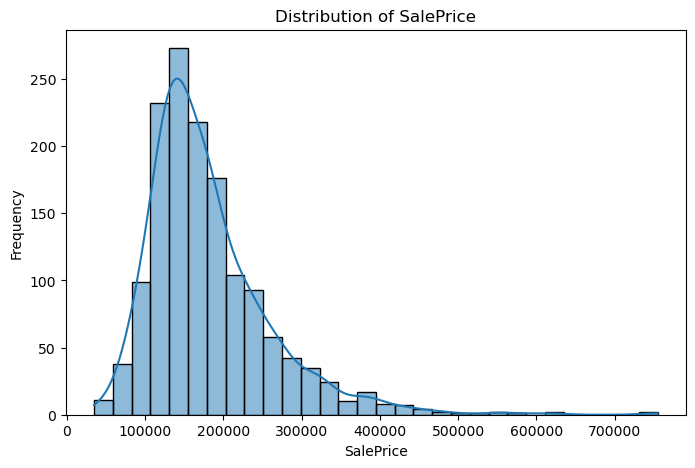

In [32]:

# SalePrice Distribution
plt.figure(figsize=(8, 5))
sns.histplot(df["SalePrice"], bins=30, kde=True)
plt.title("Distribution of SalePrice")
plt.xlabel("SalePrice")
plt.ylabel("Frequency")
plt.show()

**Correlation Heatmap**


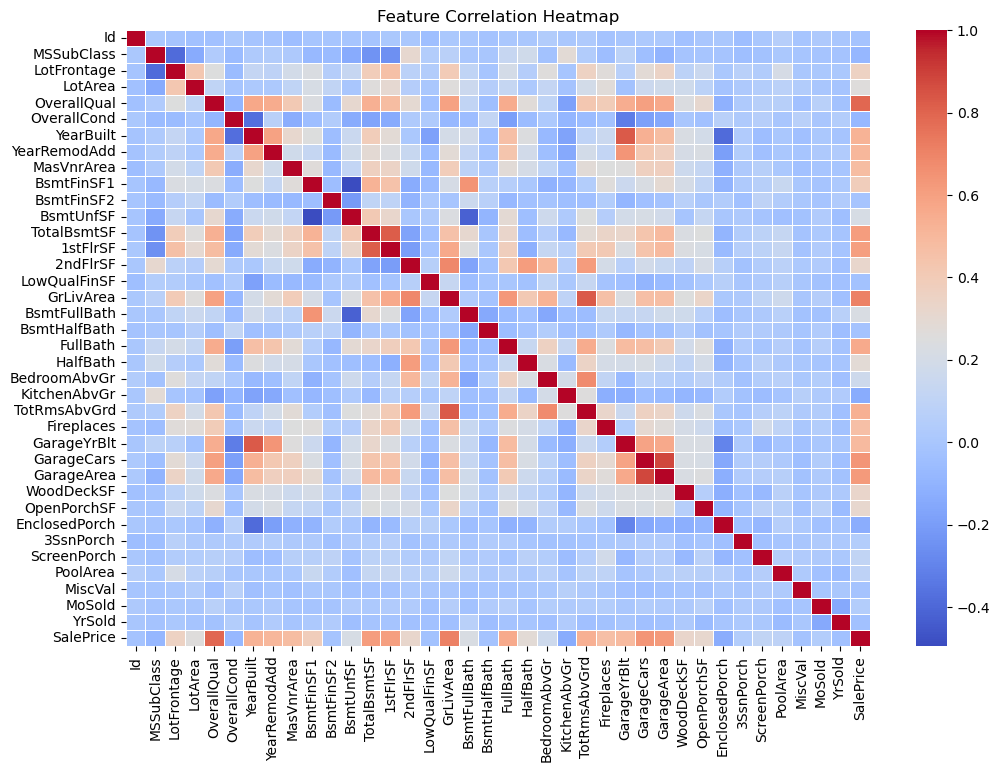

SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
Name: SalePrice, dtype: float64

In [35]:
# Correlation Heatmap
plt.figure(figsize=(12, 8))
correlation_matrix = df.corr(numeric_only=True)
sns.heatmap(correlation_matrix, cmap="coolwarm", annot=False, fmt=".2f", linewidths=0.5)
plt.title("Feature Correlation Heatmap")
plt.show()

# Top correlated features with SalePrice
top_corr_features = correlation_matrix["SalePrice"].sort_values(ascending=False).head(10)
top_corr_features

**Handling Missing Values**

In [38]:

# Drop columns with excessive missing values (more than 50% missing)
df = df.drop(columns=["Alley", "PoolQC", "Fence", "MiscFeature"], axis=1)

# Fill missing numerical values with median
num_cols = df.select_dtypes(include=["int64", "float64"]).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

# Fill missing categorical values with mode
cat_cols = df.select_dtypes(include=["object"]).columns
df[cat_cols] = df[cat_cols].fillna(df[cat_cols].mode().iloc[0])

# Verify no missing values remain
df.isnull().sum().sum()

0

**Apply Log Transformation to SalePrice**


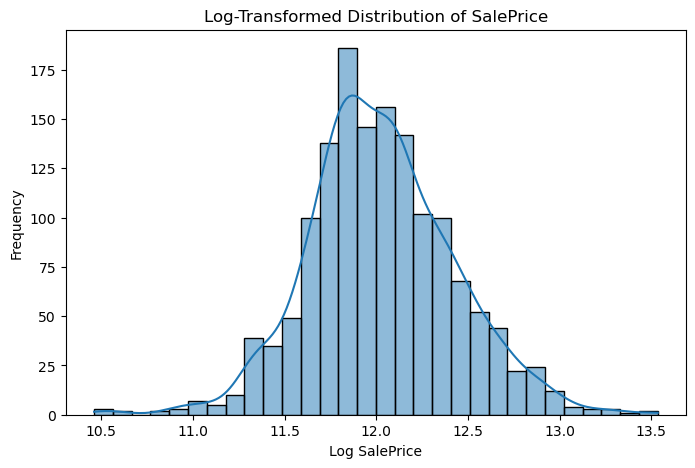

In [42]:


df["SalePrice"] = np.log1p(df["SalePrice"])

# Plot transformed SalePrice distribution
plt.figure(figsize=(8, 5))
sns.histplot(df["SalePrice"], bins=30, kde=True)
plt.title("Log-Transformed Distribution of SalePrice")
plt.xlabel("Log SalePrice")
plt.ylabel("Frequency")
plt.show()

**Boxplot for OverallQual vs SalePrice**

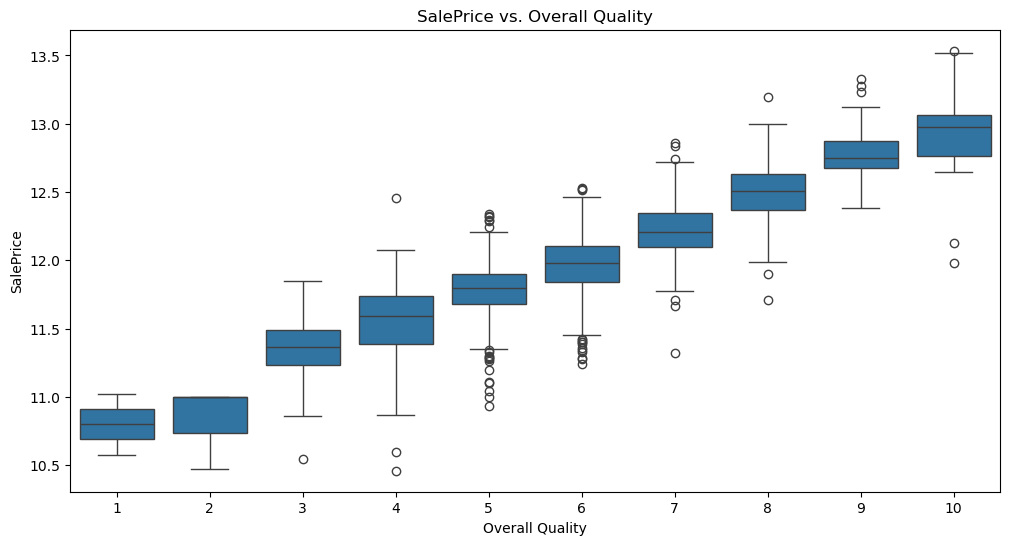

In [48]:
plt.figure(figsize=(12, 6))
sns.boxplot(x=df["OverallQual"], y=df["SalePrice"])
plt.title("SalePrice vs. Overall Quality")
plt.xlabel("Overall Quality")
plt.ylabel("SalePrice")
plt.show()


**Boxplot for YearBuilt vs SalePrice**

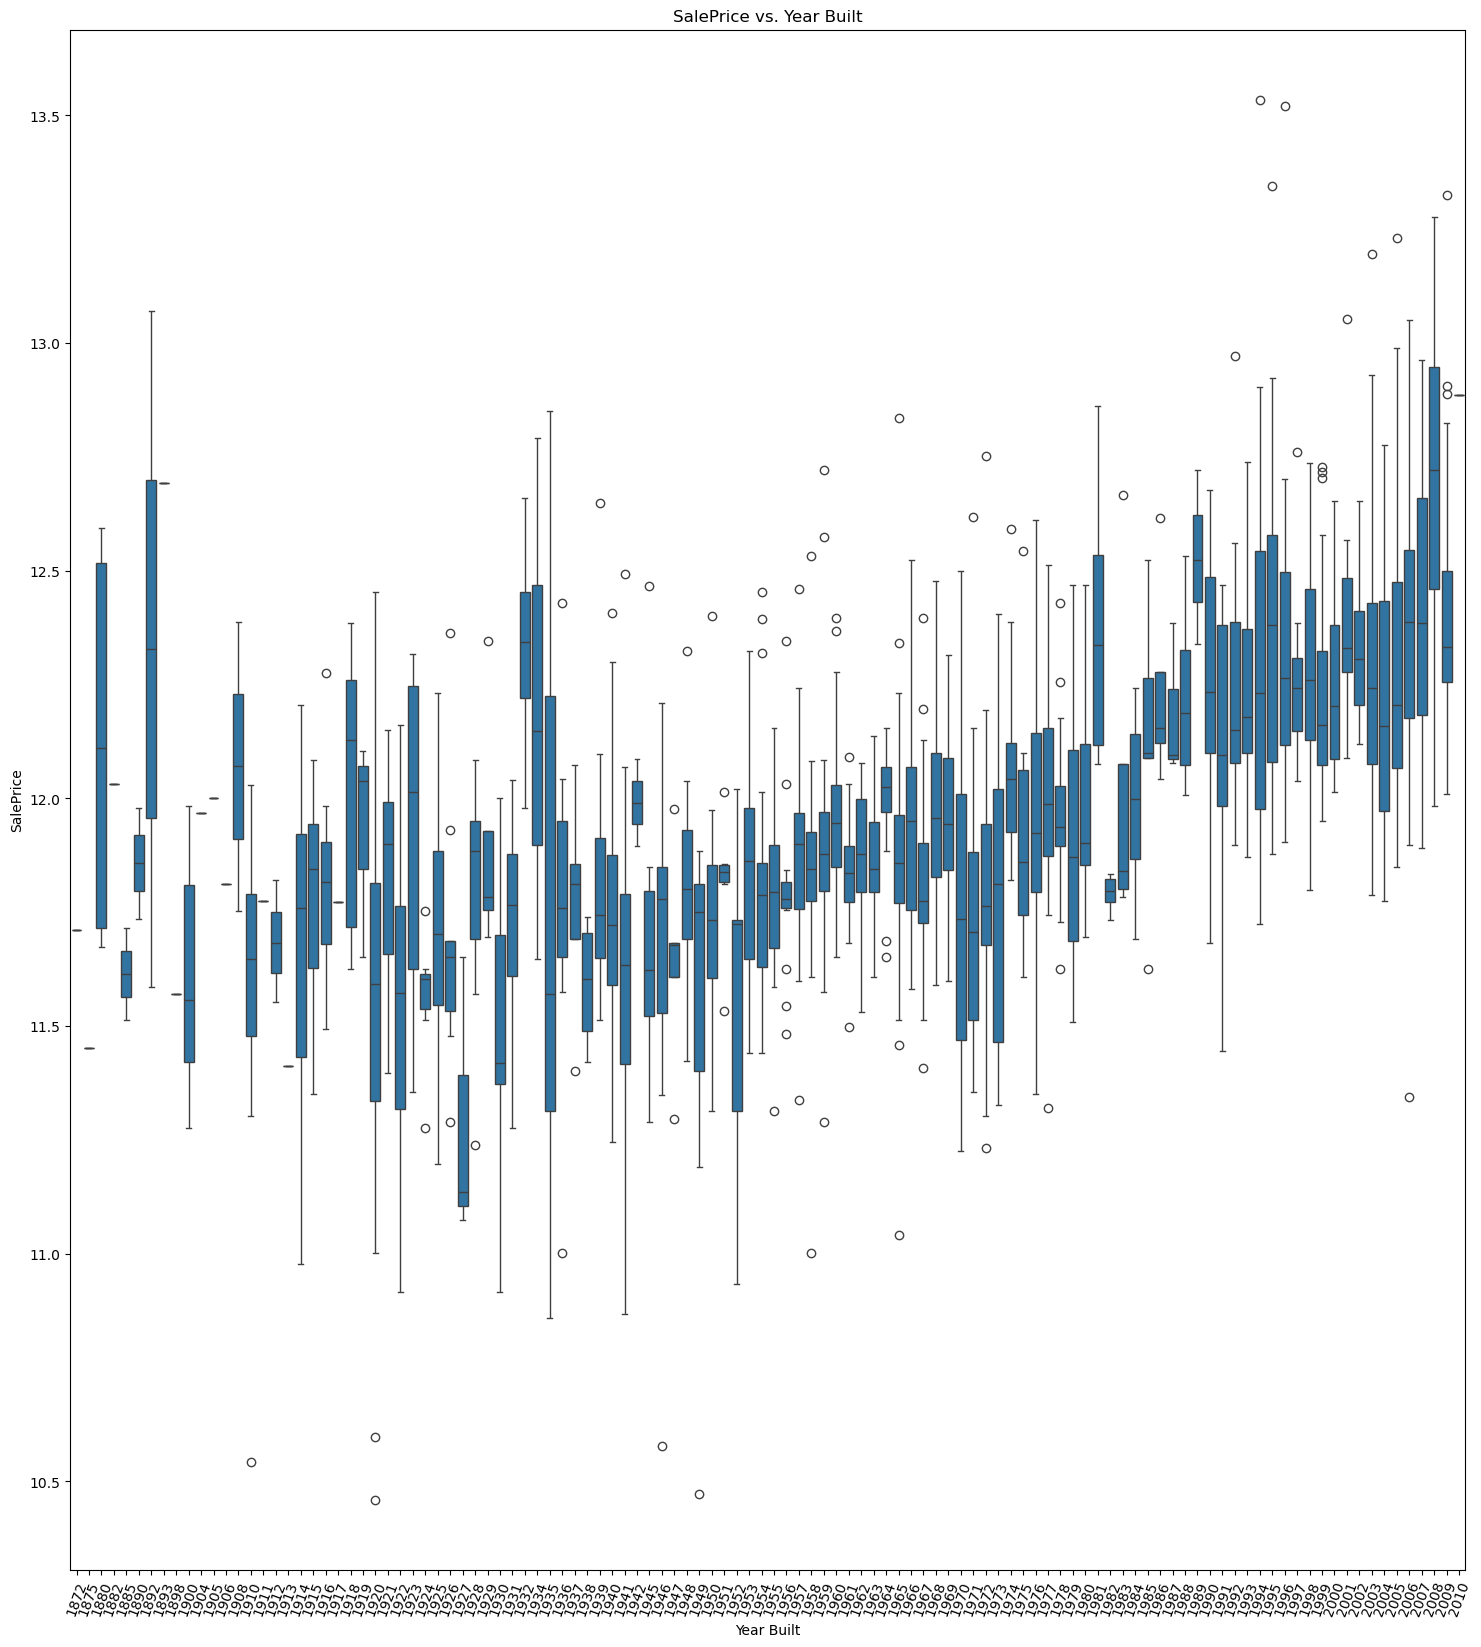

In [59]:
plt.figure(figsize=(18, 20))
sns.boxplot(x=df["YearBuilt"], y=df["SalePrice"])
plt.xticks(rotation=70)
plt.title("SalePrice vs. Year Built")
plt.xlabel("Year Built")
plt.ylabel("SalePrice")
plt.show()

**Creating a pairplot**

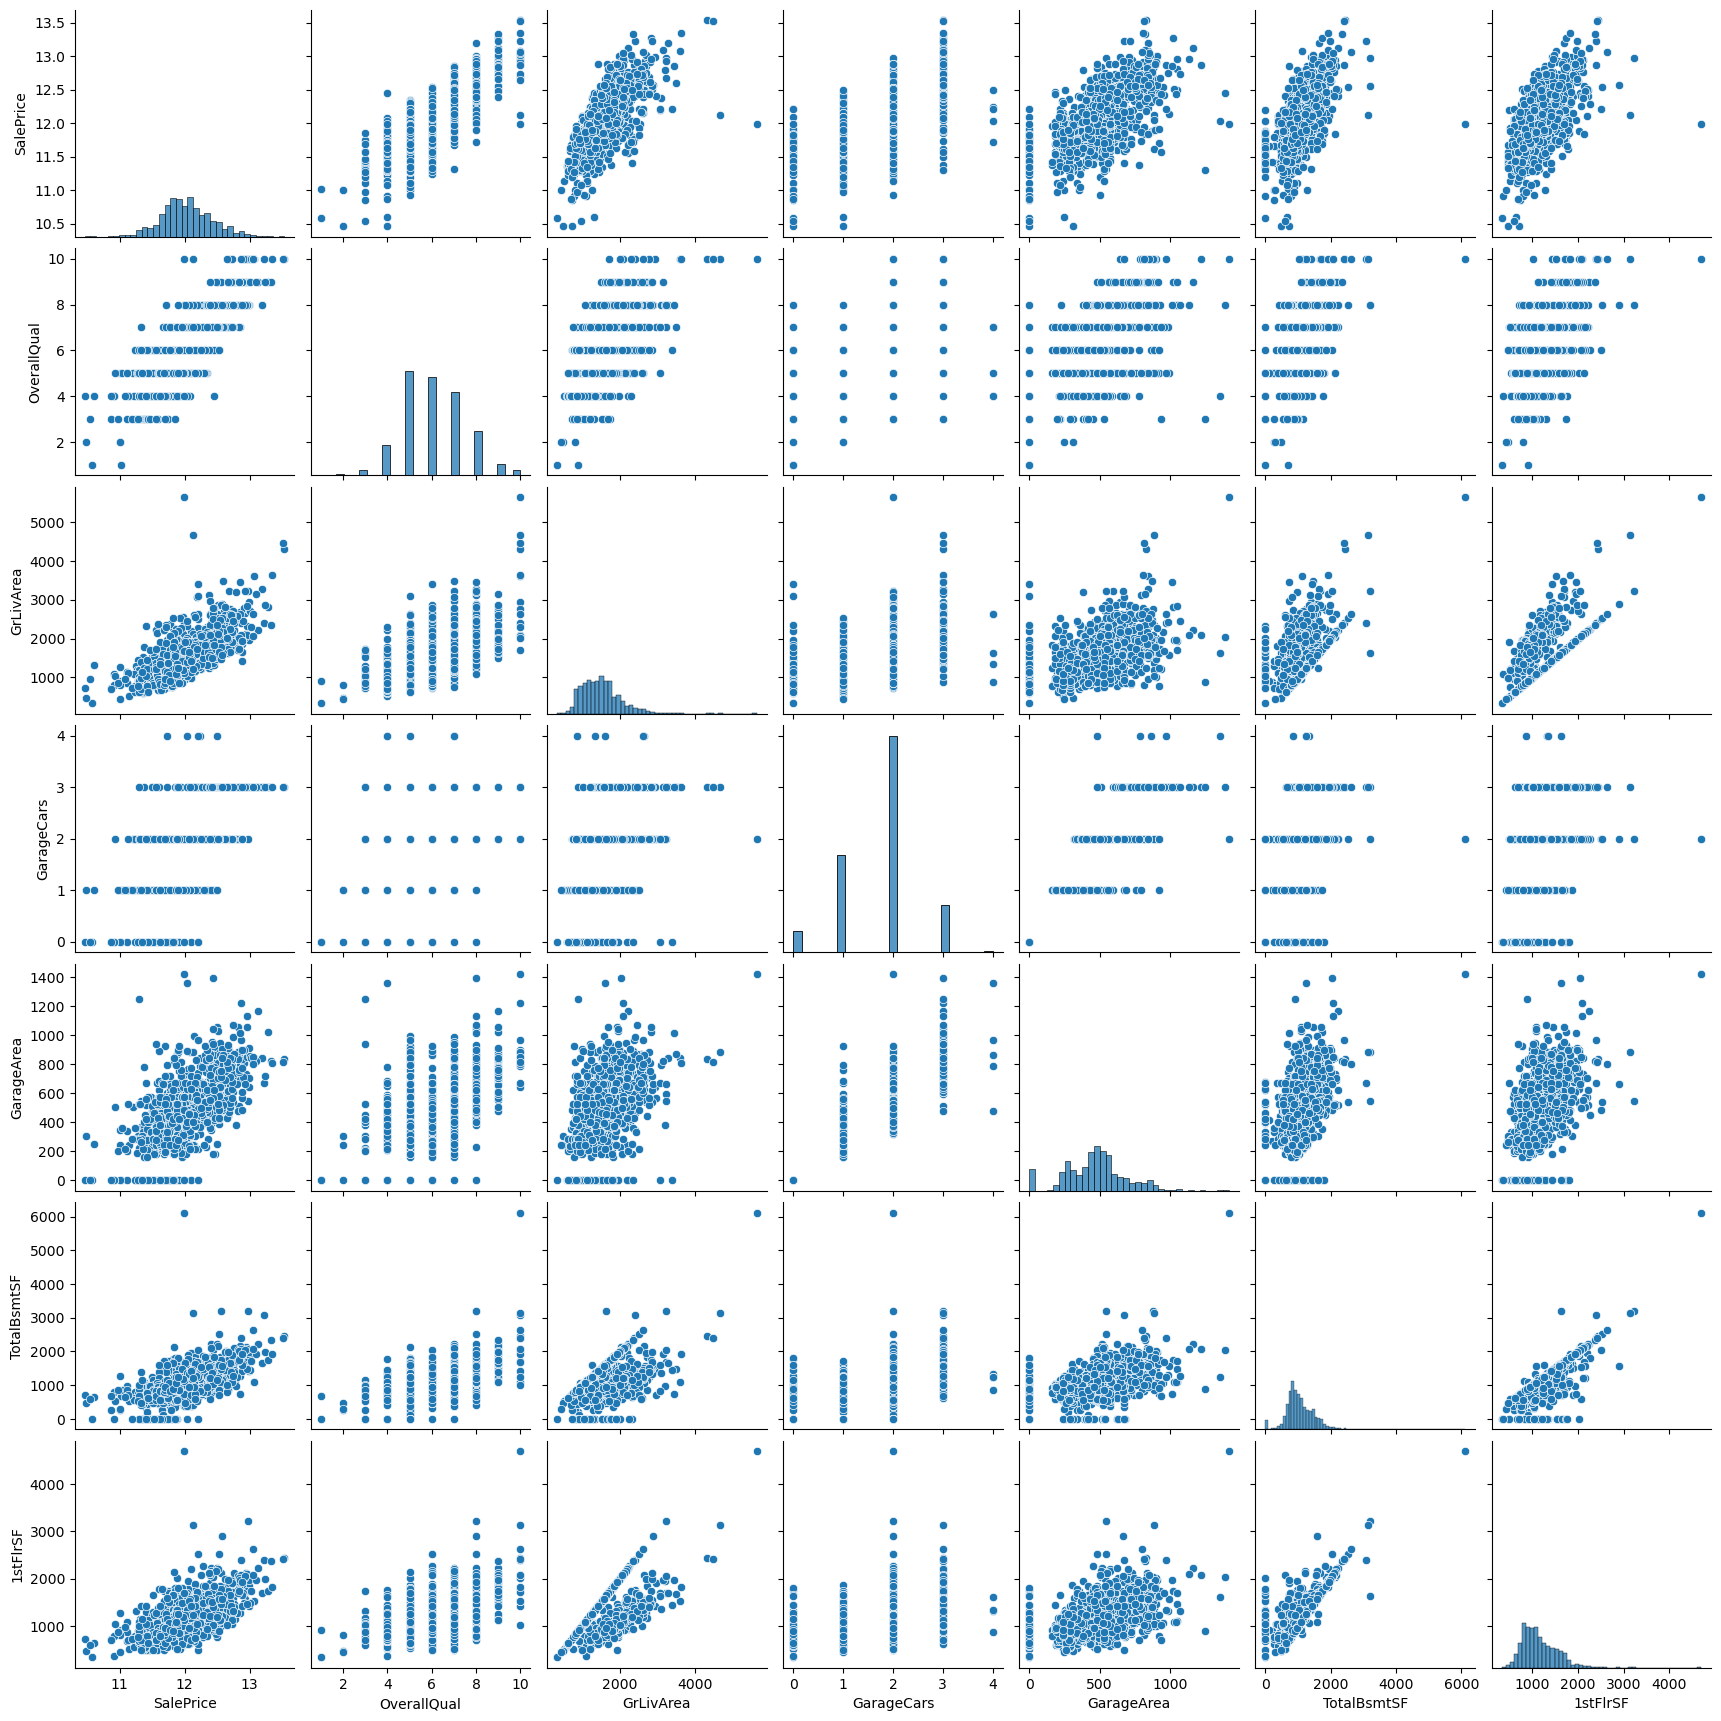

In [62]:

# Selecting highly correlated features
top_corr_features = ["SalePrice", "OverallQual", "GrLivArea", "GarageCars", "GarageArea", "TotalBsmtSF", "1stFlrSF"]

# Creating a pairplot
sns.pairplot(df[top_corr_features])
plt.show()

In [64]:
# Encoding categorical variables using one-hot encoding
df = pd.get_dummies(df, drop_first=True)

# Save the cleaned dataset for modeling
df.to_csv("cleaned_train.csv", index=False)

# Display final dataset info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Columns: 237 entries, Id to SaleCondition_Partial
dtypes: bool(199), float64(4), int64(34)
memory usage: 717.3 KB
